<a href="https://colab.research.google.com/github/AristidesAntonioOrellanaZelaya/2505442022_ORELLANA_ARISTIDES_CLAVE_E_PARCIAL_4/blob/main/Notebook/Ejercicio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [80]:
url = "https://raw.githubusercontent.com/AristidesAntonioOrellanaZelaya/2505442022_ORELLANA_ARISTIDES_CLAVE_E_PARCIAL_4/refs/heads/main/Data/clave_E_asociacion.csv"

df = pd.read_csv(url)

En este bloque se importan las librerias necesarias. Posteriormente se carga el archivo CSV asignado utilizando pd.read_csv().

In [71]:
#Mostrando primeras filas del dataset
df.head()

,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,E-T0001,E-C0068,2026-01-01,Tecnico,Calculadora,1,App
1,E-T0001,E-C0068,2026-01-01,Libros,Novela,1,App
2,E-T0001,E-C0068,2026-01-01,Arte,Pinceles,1,App
3,E-T0001,E-C0068,2026-01-01,Tecnico,Regla,1,App
4,E-T0002,E-C0056,2026-01-22,Papeleria,Lapiz,1,Web


El dataset contiene información sobre transacciones realizadas por clientes. Cada fila representa un producto comprado dentro de una transacción.

In [73]:
#VALORES NULOS
print("\nValores nulos:")
print(df.isnull().sum())




Valores nulos:
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64


Aqui se puede verificar que solo hay 1 dato nulo en la variable de canal, se encuentra en la columna 27 del archivo csv

In [74]:
#VALORES DUPLICADOS
print("\nDuplicados:")
print(df.duplicated().sum())


Duplicados:
1


In [75]:
#ESTADISTICA DESCRIPTIVA
print("\nEstadística descriptiva:")
print(df.describe())


Estadística descriptiva:
         cantidad
count  605.000000
mean     1.403306
std      0.708970
min      1.000000
25%      1.000000
50%      1.000000
75%      2.000000
max      4.000000


In [76]:
#DIMENSIONES DEL DATASET
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(605, 7)


El archivo posee 605 resgistros con 7 variables

In [77]:
#INFORMACION GENERAL DEL DATASET
print("\nInformación general:")
print(df.info())


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  605 non-null    object
 1   cliente_id      605 non-null    object
 2   fecha           605 non-null    object
 3   categoria       605 non-null    object
 4   item            605 non-null    object
 5   cantidad        605 non-null    int64 
 6   canal           604 non-null    object
dtypes: int64(1), object(6)
memory usage: 33.2+ KB
None


El dataset no presenta problemas graves de calidad de datos. Las columnas categóricas fueron detectadas correctamente como tipo objeto y la columna cantidad como numérica.

PREPARANDO LOS DATOS

In [78]:
#FRECUENCIA POR CATEGORIA Y CANALES
print("\nFRECUENCIA POR CATEGORÍA:")
print(df['categoria'].value_counts())

print("\nFRECUENCIA POR CANAL:")
print(df['canal'].value_counts())


FRECUENCIA POR CATEGORÍA:
categoria
Tecnico      151
Papeleria    129
Arte         114
Libros       111
Oficina      100
Name: count, dtype: int64

FRECUENCIA POR CANAL:
canal
Tienda      280
App         144
Web         139
Telefono     41
Name: count, dtype: int64


Aqui podemos ver la frecuencia por cada categoria y tambien por canal

In [79]:
#AGRUPANDO LOS PRODUCTOS PARA PODER ASOCIARLOS
from mlxtend.preprocessing import TransactionEncoder

# Agrupar productos por transacción
transacciones = df.groupby('transaccion_id')['item'].apply(list).tolist()

# Convertir a formato binario
te = TransactionEncoder()
te_array = te.fit(transacciones).transform(transacciones)

# Crear dataframe final
basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()

,Acuarelas,Borrador,Calculadora,Cartulina,Clips,Compas,Cuaderno,Diccionario,Engrapadora,Folder,Lapicero,Lapiz,Libro_matematica,Libro_programacion,Marcadores,Memoria_USB,Novela,Pinceles,Regla,Resaltador
0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False
2,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,True,True,False,True,False,False,False,False,False,True,True,False,True,False,False,False,False


Las reglas de asociación requieren que los datos estén en formato transaccional binario:

True: el producto fue comprado.
False: el producto no fue comprado.

Cada fila representa una transacción y cada columna un producto.

In [59]:
frecuencia_productos = basket.sum().sort_values(ascending=False)

print("\nFrecuencia de productos:")
print(frecuencia_productos)


Frecuencia de productos:
Regla                 46
Libro_programacion    45
Calculadora           43
Cuaderno              43
Memoria_USB           43
Lapicero              42
Pinceles              40
Acuarelas             37
Resaltador            31
Clips                 30
Novela                26
Libro_matematica      25
Borrador              24
Cartulina             23
Engrapadora           22
Lapiz                 19
Compas                19
Folder                17
Diccionario           15
Marcadores            14
dtype: int64


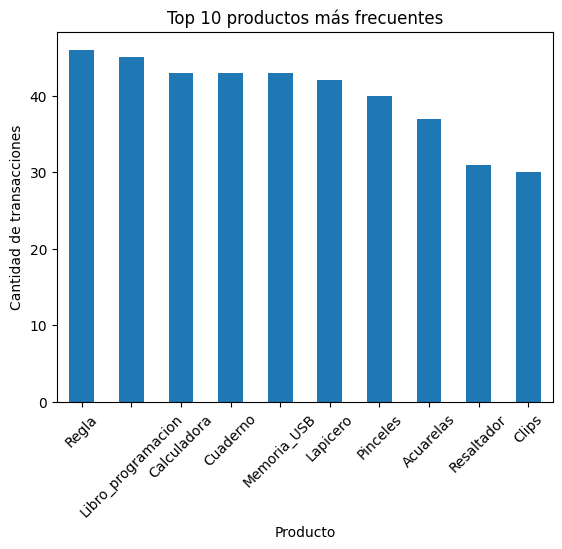

In [60]:
frecuencia_productos.head(10).plot(kind='bar')

plt.title("Top 10 productos más frecuentes")
plt.xlabel("Producto")
plt.ylabel("Cantidad de transacciones")

plt.xticks(rotation=45)

plt.show()

ALDORITMO APRIORI

In [72]:
#ALGORITMO APRIORI
frecuentes = apriori(
    basket,
    min_support=0.05,
    use_colnames=True
)

# Ordenar por soporte
frecuentes = frecuentes.sort_values(
    by='support',
    ascending=False
)

print("\nItemsets frecuentes:")
print(frecuentes.head(10))


Itemsets frecuentes:
     support              itemsets
18  0.248649               (Regla)
13  0.243243  (Libro_programacion)
15  0.232432         (Memoria_USB)
6   0.232432            (Cuaderno)
2   0.232432         (Calculadora)
10  0.227027            (Lapicero)
17  0.216216            (Pinceles)
0   0.200000           (Acuarelas)
19  0.167568          (Resaltador)
4   0.162162               (Clips)


GENERANDO LAS REGLAS

In [68]:
reglas = association_rules(
    frecuentes,
    metric="lift",
    min_threshold=1
)

print("\nCANTIDAD DE REGLAS:")
print(reglas.shape)

print("\nCOLUMNAS DE REGLAS:")
print(reglas.columns)



CANTIDAD DE REGLAS:
(20, 14)

COLUMNAS DE REGLAS:
Index(['antecedents', 'consequents', 'antecedent support',
       'consequent support', 'support', 'confidence', 'lift',
       'representativity', 'leverage', 'conviction', 'zhangs_metric',
       'jaccard', 'certainty', 'kulczynski'],
      dtype='object')


In [69]:
reglas = reglas.sort_values(
    by=["lift", "confidence"],
    ascending=False
)

TOP 10 DE REGLAS

In [70]:
top10 = reglas[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].head(10)

print("\nTOP 10 REGLAS:")
print(top10)



TOP 10 REGLAS:
               antecedents             consequents   support  confidence  \
13    (Lapicero, Cuaderno)            (Resaltador)  0.091892    0.850000   
16            (Resaltador)    (Lapicero, Cuaderno)  0.091892    0.548387   
12  (Lapicero, Resaltador)              (Cuaderno)  0.091892    0.809524   
17              (Cuaderno)  (Lapicero, Resaltador)  0.091892    0.395349   
14  (Resaltador, Cuaderno)              (Lapicero)  0.091892    0.772727   
15              (Lapicero)  (Resaltador, Cuaderno)  0.091892    0.404762   
1               (Pinceles)             (Acuarelas)  0.135135    0.625000   
0              (Acuarelas)              (Pinceles)  0.135135    0.675676   
6             (Resaltador)              (Cuaderno)  0.118919    0.709677   
7               (Cuaderno)            (Resaltador)  0.118919    0.511628   

        lift  
13  5.072581  
16  5.072581  
12  3.482835  
17  3.482835  
14  3.403680  
15  3.403680  
1   3.125000  
0   3.125000  
6   3.053263

Las reglas con mayor valor de lift representan
relaciones más fuertes entre productos.

Una confianza alta indica que cuando un cliente
compra un producto, existe una alta probabilidad
de que también compre otro producto asociado.
